# Hillstrom e-mail experiment: exploration

Working notebook for checks that shaped the pipeline in `src/`, not a polished summary. Everything below runs against the real 64,000-row file (`src/data_loader.load_hillstrom()`), as do the reports in `reports/`.

The selection examples below compare selected-sample estimates with an estimated reference from the randomized sample. Selection changes the covariate distribution and may change the target-population effect, so those differences are descriptive rather than known bias. The fully synthetic Monte Carlo benchmark supplies known targets for bias and coverage.


In [1]:
import sys
from pathlib import Path

# jupyter kernels don't add the notebook's parent directory to sys.path the way `python file.py`
# does, so `import src` fails without this (same fix app/simulator.py needs, and for the same
# reason: nbconvert's execution cwd doesn't automatically become a sys.path entry either).
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from src.config import ARM_COL, ARMS
from src.data_loader import arm_sizes, load_hillstrom, outcome_rates

df = load_hillstrom()
df.shape

(64000, 13)

## Arm balance and outcome rates

Confirms the numbers `reports/data_dictionary.md` and `reports/02_naive_estimate.md` are built on, computed directly here rather than trusted secondhand.

In [2]:
print(arm_sizes(df))
print()
print(outcome_rates(df))

segment
No E-Mail        21306
Mens E-Mail      21307
Womens E-Mail    21387
Name: count, dtype: int64

                  visit  conversion     spend
segment                                      
No E-Mail      0.106167    0.005726  0.652789
Mens E-Mail    0.182757    0.012531  1.422617
Womens E-Mail  0.151400    0.008837  1.077202


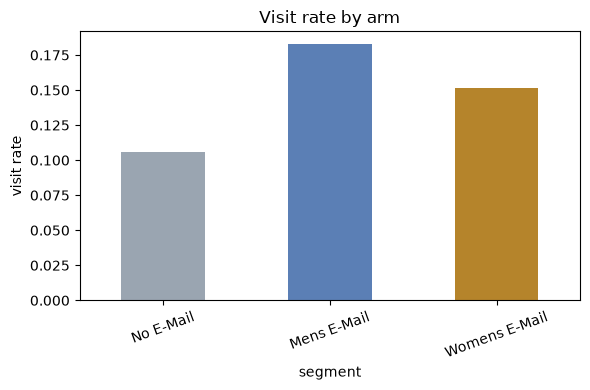

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
outcome_rates(df)["visit"].plot(kind="bar", ax=ax, color=["#9aa5b1", "#5b7fb5", "#b5842b"])
ax.set_ylabel("visit rate")
ax.set_title("Visit rate by arm")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

Creative-specific estimates differ in this randomized experiment. That motivates evaluating the three available actions, but it does not by itself establish customer-level personalization value.


## Reported spend has a spike at its observed maximum

The file contains several observations at $499 and the next-highest reported value is lower. This pattern is consistent with possible top-coding, but does not establish a cap, its mechanism, or its motive.


In [4]:
nonzero = df[df["spend"] > 0]["spend"].sort_values(ascending=False)
print("top 15 spend values:", nonzero.head(15).tolist())
print("count exactly at 499.00:", (df["spend"] == 499.0).sum())
print("next-highest value:", nonzero[nonzero < 499.0].max())

top 15 spend values: [499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 499.0, 482.31, 462.78, 444.92]
count exactly at 499.00: 12
next-highest value: 482.31


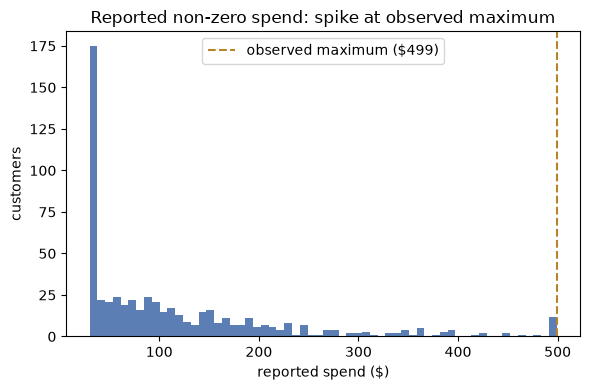

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nonzero, bins=60, color="#5b7fb5")
ax.axvline(499.0, color="#b5842b", linestyle="--", label="observed maximum ($499)")
ax.set_xlabel("reported spend ($)")
ax.set_ylabel("customers")
ax.set_title("Reported non-zero spend: spike at observed maximum")
ax.legend()
fig.tight_layout()

## Tried and rejected: using `recency` and `history` as the omitted-confounder demonstration

The first attempt reused selection on `recency` and `history`, then withheld `history` from the DML adjustment set. Its interval still contains the estimated full-randomized-sample reference. That reference is estimated for a different population, so this does not test against the selected sample's causal truth. We rejected this setup as the clean omitted-confounder demonstration because `recency` remains observed and informative about selection. The fully synthetic benchmark, with known sample-average `p1 - p0` targets, supports the bias and coverage claims.

In [6]:
from src.config import RANDOM_SEED, TREATMENT_COL
from src.confounded import dml_estimate, make_confounded_sample, naive_diff
from src.dml_ate import dml_ate

experimental_reference = dml_ate(df, TREATMENT_COL, "visit")["ate"]

sub = make_confounded_sample(
    df, ["recency", "history"], {"recency": -1, "history": 1}, strength=1.2, seed=RANDOM_SEED
)
attempt = dml_estimate(sub, "visit", drop_cols=["history"])
print("estimated reference from full randomized sample:", experimental_reference)
print("selected-sample naive difference:", naive_diff(sub, "visit"))
print("selected-sample DML estimate with history withheld:", attempt)
print(
    "Does its interval contain the full-sample estimate?",
    attempt["ci_low"] <= experimental_reference <= attempt["ci_high"],
)

C:\Users\aakas\Documents\Projects\Github Projects\Causal ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


estimated reference from full randomized sample: 0.06012814761308752
selected-sample naive difference: 0.10029009027449032
selected-sample DML estimate with history withheld: {'ate': 0.06836998291463256, 'ci_low': 0.05850643727775519, 'ci_high': 0.07823352855150993}
Does its interval contain the full-sample estimate? True


The interval check compares estimates for different populations; it is not a test against the selected sample's true causal effect. Keeping `recency` and `history` available to the estimator is a measured-adjustment diagnostic. The difference from the full randomized-sample estimate is not a numerical bias estimate.

The second example omits `newbie` from the fitted estimator. It illustrates sensitivity to a variable used in selection, but the full-sample estimate remains a reference for another population. Known-bias and coverage claims are reserved for the fully synthetic benchmark, where the generated potential-outcome probabilities are available.


In [7]:
sub2 = make_confounded_sample(df, ["newbie"], {"newbie": -1}, strength=1.5, seed=RANDOM_SEED)
newbie_withheld = dml_estimate(sub2, "visit", drop_cols=["newbie"])
print("DML estimate on selected sample with newbie withheld:", newbie_withheld)
print("Full randomized-sample estimate (different target population):", experimental_reference)
print("Descriptive estimate difference:", newbie_withheld["ate"] - experimental_reference)

DML estimate on selected sample with newbie withheld: {'ate': 0.09490164194835683, 'ci_low': 0.08718395326648076, 'ci_high': 0.1026193306302329}
Full randomized-sample estimate (different target population): 0.06012814761308752
Descriptive estimate difference: 0.034773494335269314


## Covariate distributions by arm

The descriptive balance check is in `reports/02_naive_estimate.md`. This plot shows those measured distributions; it cannot check unmeasured causes.


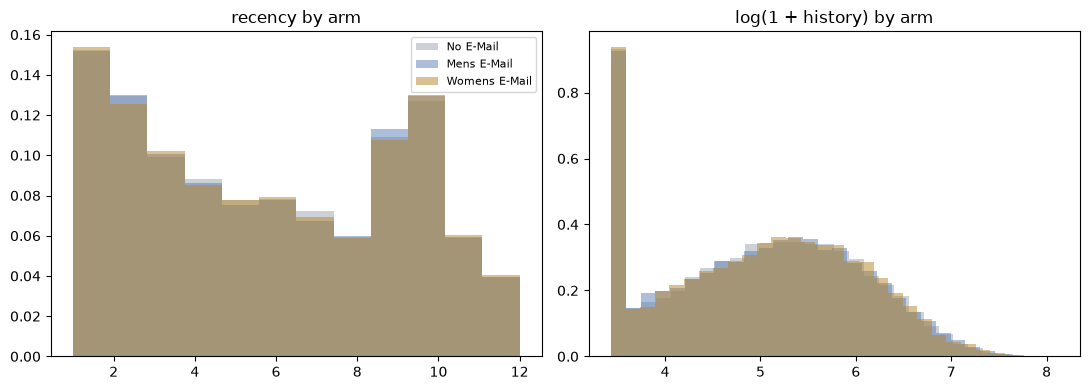

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm, color in zip(ARMS, ["#9aa5b1", "#5b7fb5", "#b5842b"], strict=True):
    sub_arm = df[df[ARM_COL] == arm]
    axes[0].hist(sub_arm["recency"], bins=12, alpha=0.5, label=arm, color=color, density=True)
    axes[1].hist(
        np.log1p(sub_arm["history"]), bins=30, alpha=0.5, label=arm, color=color, density=True
    )
axes[0].set_title("recency by arm")
axes[1].set_title("log(1 + history) by arm")
axes[0].legend(fontsize=8)
fig.tight_layout()

The measured distributions are similar across arms, consistent with the randomized design. This is a visual check alongside the standardized-difference table, not a proof of balance on unmeasured variables.
